In [1]:
from sklearn.datasets import load_iris
iris=load_iris()

In [3]:
import pandas as pd
X=iris.data
y=iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df.shape

(150, 5)

In [6]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [7]:
df=df[df['target']!=0][['sepal width (cm)','petal length (cm)','target']]

In [8]:
df.head()

,sepal width (cm),petal length (cm),target
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


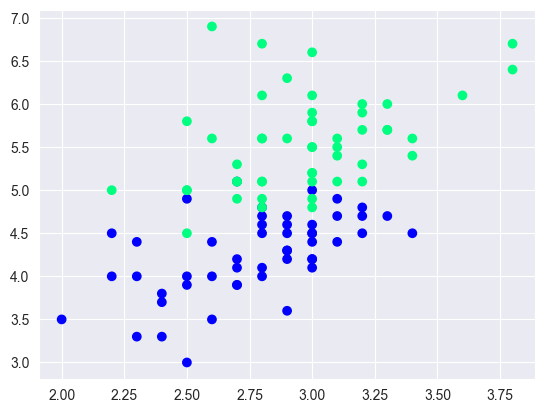

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['target'],cmap='winter')

In [10]:
df.shape

(100, 3)

In [11]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [12]:
df_train

,sepal width (cm),petal length (cm),target
149,3.0,5.1,2
113,2.5,5.0,2
88,3.0,4.1,1
109,3.6,6.1,2
67,2.7,4.1,1
89,2.5,4.0,1
77,3.0,5.0,1
121,2.8,4.9,2
145,3.0,5.2,2
119,2.2,5.0,2


In [14]:
X_test=df_val.iloc[:,0:2].values

In [15]:
y_test=df_val.iloc[:,-1].values

In [17]:
X_test

array([[2.7, 3.9],
       [3.2, 4.5],
       [2.8, 4.8],
       [3. , 6.1],
       [2.7, 4.2]])

In [18]:
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal width (cm),petal length (cm),target
119,2.2,5.0,2
67,2.7,4.1,1
109,3.6,6.1,2
149,3.0,5.1,2
121,2.8,4.9,2
88,3.0,4.1,1
77,3.0,5.0,1
67,2.7,4.1,1


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [21]:
dt_bag1=DecisionTreeClassifier()


In [22]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred=clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

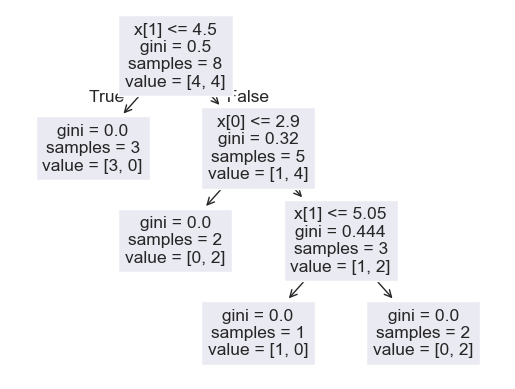

/Users/kpvarma/PycharmProjects/100_days_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kpvarma/PycharmProjects/100_days_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


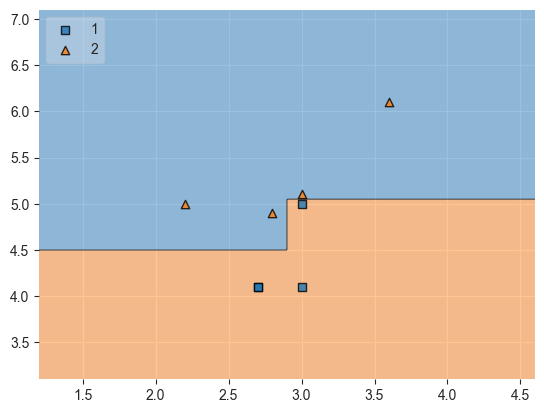

In [23]:
evaluate(dt_bag1,X,y)

In [24]:
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal width (cm),petal length (cm),target
77,3.0,5.0,1
113,2.5,5.0,2
89,2.5,4.0,1
113,2.5,5.0,2
109,3.6,6.1,2
89,2.5,4.0,1
119,2.2,5.0,2
149,3.0,5.1,2


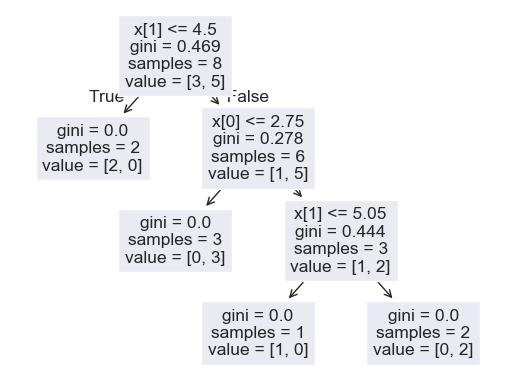

1.0


/Users/kpvarma/PycharmProjects/100_days_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kpvarma/PycharmProjects/100_days_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


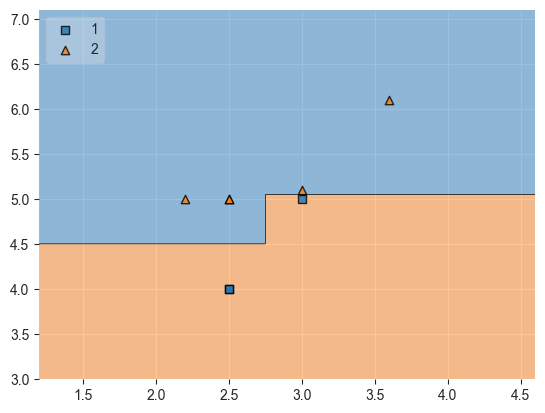

In [25]:
dt_bag2=DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [26]:
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal width (cm),petal length (cm),target
67,2.7,4.1,1
89,2.5,4.0,1
89,2.5,4.0,1
88,3.0,4.1,1
113,2.5,5.0,2
149,3.0,5.1,2
89,2.5,4.0,1
149,3.0,5.1,2


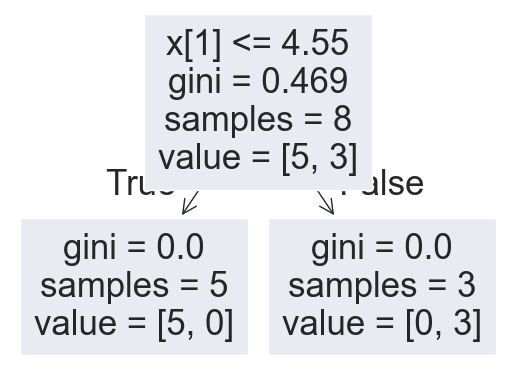

0.8


/Users/kpvarma/PycharmProjects/100_days_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kpvarma/PycharmProjects/100_days_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


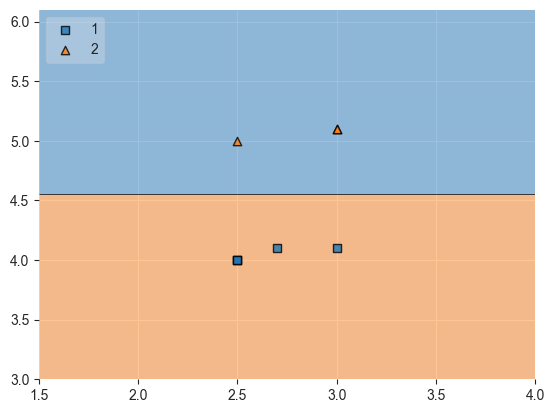

In [27]:
dt_bag3=DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [28]:
df_test

,sepal width (cm),petal length (cm),target
110,3.2,5.1,2
100,3.3,6.0,2
114,2.8,5.1,2
69,2.5,3.9,1
138,3.0,4.8,2
